# Failure Risk Scoring

This notebook extends the selected Gradient Boosting classifier into an interpretable **0–100 machine failure risk score** for a future predictive-maintenance dashboard.

The score prioritizes inspection and intervention; it does not replace engineering judgment. To prevent target leakage, identifiers and the failure-mode labels `TWF`, `HDF`, `PWF`, `OSF`, and `RNF` are never predictors. Thresholds are learned from out-of-fold training predictions, leaving the holdout set for final evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (average_precision_score, confusion_matrix,
                             precision_recall_curve, precision_score, recall_score)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", context="notebook")

## 1. Load and validate the data

AI4I rows are operating observations, not a live fleet snapshot. Risk-category counts therefore describe **test-set observations**, not unique physical machines. A production system would score the latest observation or time window associated with each physical asset.

In [2]:
df = pd.read_csv("../data/raw/ai4i2020.csv")

target_column = "Machine failure"
leakage_columns = ["TWF", "HDF", "PWF", "OSF", "RNF"]
identifier_columns = ["UDI", "Product ID"]
base_features = ["Type", "Air temperature [K]", "Process temperature [K]",
                 "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]
required = identifier_columns + base_features + [target_column] + leakage_columns
missing = sorted(set(required) - set(df.columns))
assert not missing, f"Missing expected columns: {missing}"
print(f"Dataset shape: {df.shape}")
print(f"Failure prevalence: {df[target_column].mean():.2%}")
df.head()

Dataset shape: (10000, 14)
Failure prevalence: 3.39%


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 2. Recreate the engineered feature set

The features match notebook 02. **Temperature difference** captures thermal separation, **Power proxy** combines speed and torque, and **Mechanical strain proxy** combines torque and wear. The latter two are interactions, not calibrated physical measurements.

In [3]:
X = df[base_features].copy()
y = df[target_column].copy()
X["Temperature difference"] = X["Process temperature [K]"] - X["Air temperature [K]"]
X["Power proxy"] = X["Rotational speed [rpm]"] * X["Torque [Nm]"]
X["Mechanical strain proxy"] = X["Torque [Nm]"] * X["Tool wear [min]"]
for forbidden in identifier_columns + leakage_columns + [target_column]:
    assert forbidden not in X.columns
X.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature difference,Power proxy,Mechanical strain proxy
0,M,298.1,308.6,1551,42.8,0,10.5,66382.8,0.0
1,L,298.2,308.7,1408,46.3,3,10.5,65190.4,138.9
2,L,298.1,308.5,1498,49.4,5,10.4,74001.2,247.0
3,L,298.2,308.6,1433,39.5,7,10.4,56603.5,276.5
4,L,298.2,308.7,1408,40.0,9,10.5,56320.0,360.0


## 3. Split the data and build the pipeline

The stratified 80/20 split exactly follows notebook 02. Encoding and scaling stay inside the pipeline so future rows receive preprocessing learned only from training data.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
split_summary = pd.DataFrame({
    "Rows": [len(y_train), len(y_test)],
    "Failures": [int(y_train.sum()), int(y_test.sum())],
    "Failure rate": [y_train.mean(), y_test.mean()],
}, index=["Train", "Test"])
display(split_summary.style.format({"Failure rate": "{:.2%}"}))

categorical_features = ["Type"]
numerical_features = [c for c in X.columns if c != "Type"]
preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("numerical", StandardScaler(), numerical_features),
])
risk_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42)),
])
risk_model

,Rows,Failures,Failure rate
Train,8000,271,3.39%
Test,2000,68,3.40%


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float

## 4. Learn non-arbitrary thresholds from training probabilities

Five-fold out-of-fold probabilities let every training row be scored by a model that did not train on it. Three operational criteria define the boundaries:

1. **Medium:** highest precision while retaining at least 90% recall—a broad screening tier.
2. **High:** highest recall while reaching at least 90% precision—credible enough for prompt investigation.
3. **Critical:** highest recall while reaching at least 95% precision—the strongest escalation.

These targets are transparent working assumptions. A real factory should replace them using failure costs, inspection capacity, and safety requirements.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_probability = cross_val_predict(
    risk_model, X_train, y_train, cv=cv, method="predict_proba"
)[:, 1]
oof_precision, oof_recall, candidate_thresholds = precision_recall_curve(
    y_train, oof_probability
)
threshold_table = pd.DataFrame({
    "threshold": candidate_thresholds,
    "precision": oof_precision[:-1],
    "recall": oof_recall[:-1],
})
threshold_table["f1"] = (
    2 * threshold_table.precision * threshold_table.recall
    / (threshold_table.precision + threshold_table.recall).replace(0, np.nan)
)

def best_precision_at_recall(minimum):
    eligible = threshold_table[threshold_table.recall >= minimum]
    return eligible.sort_values(["precision", "threshold"], ascending=[False, False]).iloc[0]

def best_recall_at_precision(minimum):
    eligible = threshold_table[threshold_table.precision >= minimum]
    return eligible.sort_values(["recall", "threshold"], ascending=[False, True]).iloc[0]

medium_choice = best_precision_at_recall(0.90)
high_choice = best_recall_at_precision(0.90)
critical_choice = best_recall_at_precision(0.95)
best_f1_choice = threshold_table.loc[threshold_table.f1.idxmax()]
medium_threshold = float(medium_choice.threshold)
high_threshold = float(high_choice.threshold)
critical_threshold = float(critical_choice.threshold)
assert 0 < medium_threshold < high_threshold < critical_threshold < 1

threshold_selection = pd.DataFrame({
    "Role": ["Medium: recall ≥ 90%", "High: precision ≥ 90%",
             "Critical: precision ≥ 95%", "Reference: maximum F1"],
    "Threshold": [medium_threshold, high_threshold, critical_threshold, best_f1_choice.threshold],
    "OOF precision": [medium_choice.precision, high_choice.precision,
                      critical_choice.precision, best_f1_choice.precision],
    "OOF recall": [medium_choice.recall, high_choice.recall,
                   critical_choice.recall, best_f1_choice.recall],
    "OOF F1": [medium_choice.f1, high_choice.f1, critical_choice.f1, best_f1_choice.f1],
})
threshold_selection.style.format({
    "Threshold": "{:.4f}", "OOF precision": "{:.3f}",
    "OOF recall": "{:.3f}", "OOF F1": "{:.3f}"
})

,Role,Threshold,OOF precision,OOF recall,OOF F1
0,Medium: recall ≥ 90%,0.0439,0.551,0.900,0.683
1,High: precision ≥ 90%,0.2324,0.902,0.849,0.875
2,Critical: precision ≥ 95%,0.4279,0.953,0.830,0.888
3,Reference: maximum F1,0.5473,0.978,0.819,0.892


### Precision–recall trade-off and candidate confusion matrices

For rare failures, this curve is more useful than accuracy. Lower thresholds catch more failures but create inspection work; higher thresholds improve alert credibility but can miss failures. Confusion matrices translate that trade-off into false alarms and missed events.

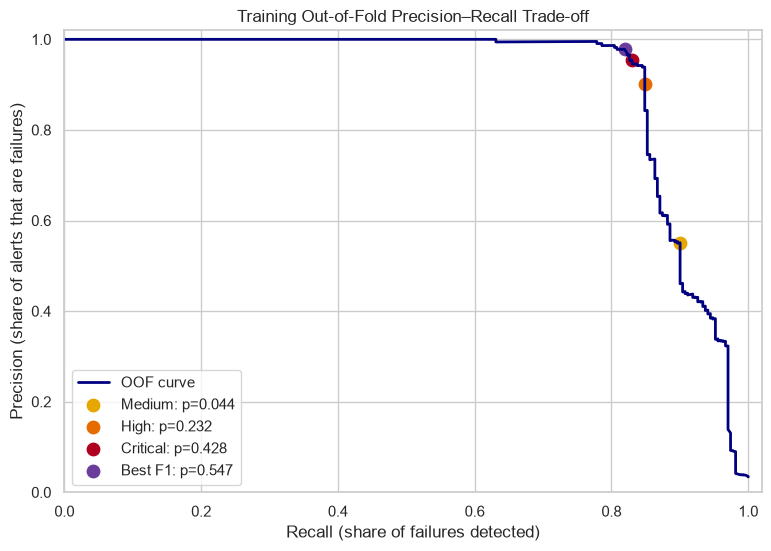

Out-of-fold average precision: 0.909


,Threshold,TN,FP,FN,TP,Precision,Recall
Boundary,,,,,,,
Medium,0.0439,7530,199,27,244,0.551,0.900
High,0.2324,7704,25,41,230,0.902,0.849
Critical,0.4279,7718,11,46,225,0.953,0.830
Conventional 0.50,0.5000,7721,8,47,224,0.966,0.827
Maximum OOF F1,0.5473,7724,5,49,222,0.978,0.819


In [6]:
plt.figure(figsize=(9, 6))
plt.plot(oof_recall, oof_precision, color="navy", linewidth=2, label="OOF curve")
for label, choice, color in [
    ("Medium", medium_choice, "#e6a700"), ("High", high_choice, "#e66b00"),
    ("Critical", critical_choice, "#b00020"), ("Best F1", best_f1_choice, "#6a3d9a")
]:
    plt.scatter(choice.recall, choice.precision, s=80, color=color,
                label=f"{label}: p={choice.threshold:.3f}")
plt.xlabel("Recall (share of failures detected)")
plt.ylabel("Precision (share of alerts that are failures)")
plt.title("Training Out-of-Fold Precision–Recall Trade-off")
plt.xlim(0, 1.02); plt.ylim(0, 1.02); plt.legend(loc="lower left"); plt.show()
print(f"Out-of-fold average precision: {average_precision_score(y_train, oof_probability):.3f}")

candidate_rows = []
boundaries = {"Medium": medium_threshold, "High": high_threshold,
              "Critical": critical_threshold, "Conventional 0.50": 0.50,
              "Maximum OOF F1": float(best_f1_choice.threshold)}
for name, threshold in boundaries.items():
    pred = (oof_probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, pred).ravel()
    candidate_rows.append({"Boundary": name, "Threshold": threshold,
                           "TN": tn, "FP": fp, "FN": fn, "TP": tp,
                           "Precision": precision_score(y_train, pred, zero_division=0),
                           "Recall": recall_score(y_train, pred, zero_division=0)})
candidate_evaluation = pd.DataFrame(candidate_rows).set_index("Boundary")
candidate_evaluation.style.format({"Threshold": "{:.4f}",
                                    "Precision": "{:.3f}", "Recall": "{:.3f}"})

## 5. Fit the model and create holdout risk scores

The final pipeline fits all training rows. The Gradient Boosting `predict_proba()` output is used here as an **uncalibrated model-derived risk score**. A score of 80/100 should not yet be interpreted as an empirically validated 80% real-world probability of failure. Probability calibration will be evaluated separately. Multiplying the model output by 100 changes only its display scale.

In [7]:
risk_model.fit(X_train, y_train)
test_probability = risk_model.predict_proba(X_test)[:, 1]
risk_labels = ["Low Risk", "Medium Risk", "High Risk", "Critical Risk"]
risk_bins = [-np.inf, medium_threshold, high_threshold, critical_threshold, np.inf]

results = pd.DataFrame({
    "actual_failure": y_test.to_numpy(),
    "uncalibrated_model_probability": test_probability,
    "risk_score": test_probability * 100,
})
results["risk_category"] = pd.cut(
    results.uncalibrated_model_probability, bins=risk_bins,
    labels=risk_labels, right=False, ordered=True
)
results.head(10).style.format({"uncalibrated_model_probability": "{:.4f}",
                               "risk_score": "{:.2f}"})

,actual_failure,uncalibrated_model_probability,risk_score,risk_category
0,0,0.0051,0.51,Low Risk
1,0,0.0012,0.12,Low Risk
2,0,0.0421,4.21,Low Risk
3,0,0.0012,0.12,Low Risk
4,0,0.0065,0.65,Low Risk
5,0,0.0015,0.15,Low Risk
6,0,0.0168,1.68,Low Risk
7,0,0.0015,0.15,Low Risk
8,0,0.0012,0.12,Low Risk
9,0,0.0011,0.11,Low Risk


## 6. Model-score distributions by actual outcome

A useful model-derived risk score moves failures toward the high end and non-failures toward the low end. Overlap matters: low-scored failures become missed events, while high-scored non-failures become avoidable alerts. The logarithmic x-axis exposes the dense low-score region. These distributions assess ranking and separation, not probability calibration.

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
actual_failure,,,,,,,,,,,,
Actual non-failure,1932.0,0.006544,0.024964,0.000805,0.001175,0.001209,0.001323,0.002251,0.005706,0.026413,0.101171,0.438411
Actual failure,68.0,0.777806,0.344889,0.001209,0.044491,0.860656,0.940258,0.976515,0.982576,0.986857,0.998716,0.999957


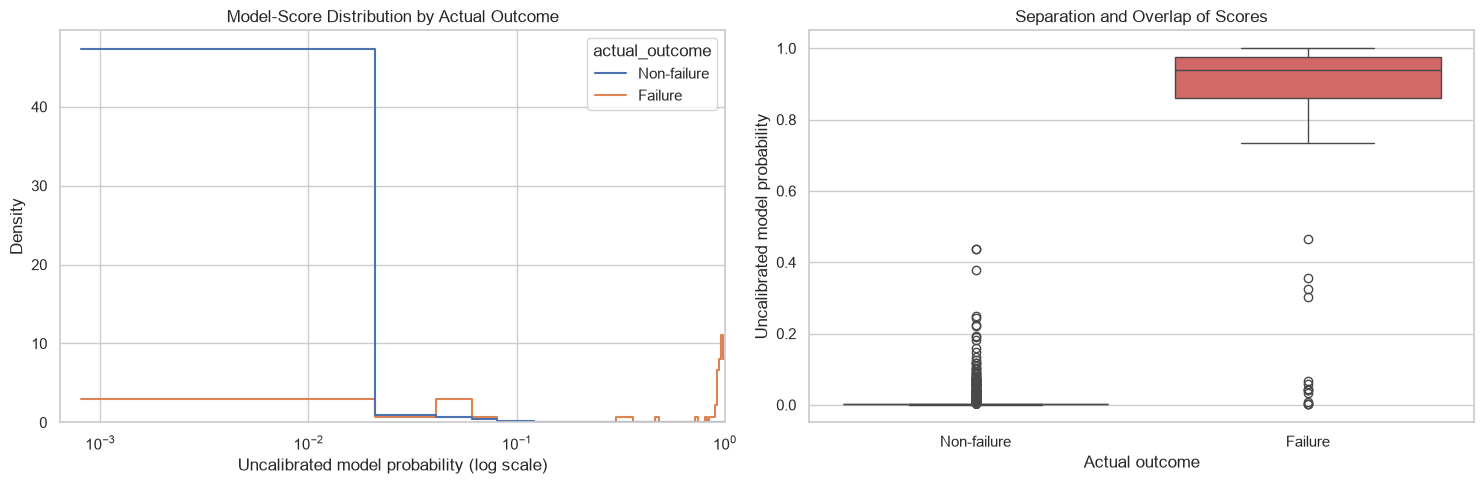

In [8]:
model_score_summary = (
    results.groupby("actual_failure")["uncalibrated_model_probability"]
    .describe(percentiles=[.10, .25, .50, .75, .90, .95, .99])
    .rename(index={0: "Actual non-failure", 1: "Actual failure"})
)
display(model_score_summary)

plot_data = results.assign(
    actual_outcome=results.actual_failure.map({0: "Non-failure", 1: "Failure"})
)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data=plot_data, x="uncalibrated_model_probability", hue="actual_outcome",
             bins=50, stat="density", common_norm=False, element="step", fill=False, ax=axes[0])
axes[0].set_xscale("log"); axes[0].set_xlim(max(test_probability.min() * .8, 1e-5), 1)
axes[0].set_xlabel("Uncalibrated model probability (log scale)")
axes[0].set_title("Model-Score Distribution by Actual Outcome")
sns.boxplot(data=plot_data, x="actual_outcome", y="uncalibrated_model_probability",
            hue="actual_outcome", palette={"Non-failure": "#4c78a8", "Failure": "#e45756"},
            legend=False, ax=axes[1])
axes[1].set_xlabel("Actual outcome"); axes[1].set_ylabel("Uncalibrated model probability")
axes[1].set_title("Separation and Overlap of Scores")
plt.tight_layout(); plt.show()

## 7. Risk Category Profile

The fixed training-derived boundaries are now applied to the holdout observations. Category size represents the review workload implied by the policy, while the observed failure rate checks whether higher categories correspond to greater realized risk. These are counts of **observations**, not unique physical machines.

The High Risk category contains only a small number of holdout observations. Its observed failure rate is therefore statistically unstable and should be interpreted cautiously rather than treated as a precise population estimate.

,number_of_observations,percentage_of_holdout_observations,number_of_actual_failures,actual_failure_rate
risk_category,,,,
Low Risk,1874,93.70%,7,0.37%
Medium Risk,63,3.15%,3,4.76%
High Risk,6,0.30%,3,50.00%
Critical Risk,57,2.85%,55,96.49%


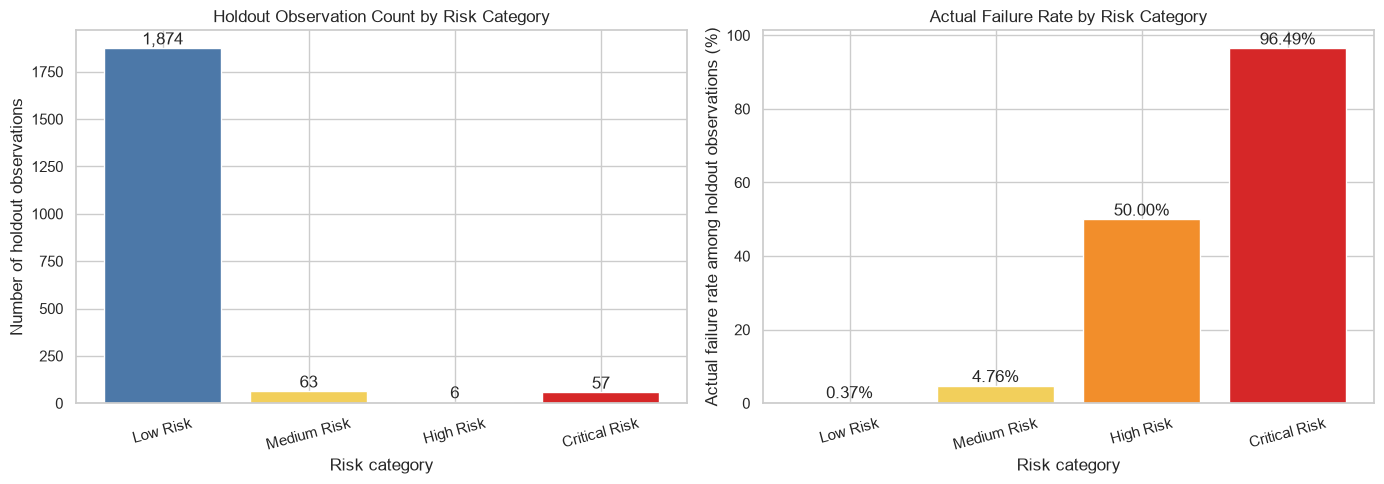

In [9]:
category_order = ["Low Risk", "Medium Risk", "High Risk", "Critical Risk"]

risk_category_summary = (
    results.groupby("risk_category", observed=False)
    .agg(
        number_of_observations=("actual_failure", "size"),
        number_of_actual_failures=("actual_failure", "sum"),
        actual_failure_rate=("actual_failure", "mean"),
    )
    .reindex(category_order)
)
risk_category_summary["percentage_of_holdout_observations"] = (
    risk_category_summary["number_of_observations"] / len(results)
)
risk_category_summary = risk_category_summary[[
    "number_of_observations",
    "percentage_of_holdout_observations",
    "number_of_actual_failures",
    "actual_failure_rate",
]]
risk_category_summary.index.name = "risk_category"

assert risk_category_summary["number_of_observations"].sum() == len(y_test) == 2000
assert risk_category_summary["number_of_actual_failures"].sum() == int(y_test.sum()) == 68

display(risk_category_summary.style.format({
    "percentage_of_holdout_observations": "{:.2%}",
    "actual_failure_rate": "{:.2%}",
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
category_colors = ["#4c78a8", "#f2cf5b", "#f28e2b", "#d62728"]

counts = risk_category_summary["number_of_observations"]
axes[0].bar(category_order, counts, color=category_colors)
axes[0].set_title("Holdout Observation Count by Risk Category")
axes[0].set_xlabel("Risk category")
axes[0].set_ylabel("Number of holdout observations")
axes[0].tick_params(axis="x", rotation=15)
for index, count in enumerate(counts):
    axes[0].text(index, count + 20, f"{count:,}", ha="center")

failure_rates = risk_category_summary["actual_failure_rate"] * 100
axes[1].bar(category_order, failure_rates, color=category_colors)
axes[1].set_title("Actual Failure Rate by Risk Category")
axes[1].set_xlabel("Risk category")
axes[1].set_ylabel("Actual failure rate among holdout observations (%)")
axes[1].tick_params(axis="x", rotation=15)
for index, rate in enumerate(failure_rates):
    axes[1].text(index, rate + 1, f"{rate:.2f}%", ha="center")

plt.tight_layout()
plt.show()

## 8. False negatives and false positives

For screening, every Medium-or-higher observation is an alert. A **false negative** is an actual failure left Low Risk—the costliest error when downtime or safety consequences are severe. A **false positive** is a non-failure escalated for review; it consumes capacity, though it may still flag an early condition absent from the binary label. Stricter boundaries show how escalation policy changes workload.

In [10]:
holdout_rows = []
for name, threshold in {"Medium-or-higher": medium_threshold,
                        "High-or-higher": high_threshold,
                        "Critical only": critical_threshold,
                        "Conventional 0.50": 0.50}.items():
    pred = (test_probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    holdout_rows.append({"Policy": name, "Threshold": threshold,
                         "TN": tn, "FP": fp, "FN": fn, "TP": tp,
                         "Precision": precision_score(y_test, pred, zero_division=0),
                         "Recall": recall_score(y_test, pred, zero_division=0)})
holdout_evaluation = pd.DataFrame(holdout_rows).set_index("Policy")
display(holdout_evaluation.style.format({"Threshold": "{:.4f}",
                                         "Precision": "{:.3f}", "Recall": "{:.3f}"}))

medium_alert = test_probability >= medium_threshold
false_negative_mask = (y_test.to_numpy() == 1) & ~medium_alert
false_positive_mask = (y_test.to_numpy() == 0) & medium_alert
false_negatives = results.loc[false_negative_mask].sort_values("risk_score", ascending=False)
false_positives = results.loc[false_positive_mask].sort_values("risk_score", ascending=False)

print(f"False negatives at Medium screening boundary: {len(false_negatives)}")
print(f"False positives at Medium screening boundary: {len(false_positives)}")
print()
print("False negatives (actual failures scored Low Risk):")
display(false_negatives.style.format({"uncalibrated_model_probability": "{:.4f}",
                                      "risk_score": "{:.2f}"}))
print("False positives (20 highest-risk rows at most):")
display(false_positives.head(20).style.format({"uncalibrated_model_probability": "{:.4f}",
                                               "risk_score": "{:.2f}"}))

,Threshold,TN,FP,FN,TP,Precision,Recall
Policy,,,,,,,
Medium-or-higher,0.0439,1867,65,7,61,0.484,0.897
High-or-higher,0.2324,1927,5,10,58,0.921,0.853
Critical only,0.4279,1930,2,13,55,0.965,0.809
Conventional 0.50,0.5000,1932,0,14,54,1.000,0.794


False negatives at Medium screening boundary: 7
False positives at Medium screening boundary: 65

False negatives (actual failures scored Low Risk):


,actual_failure,uncalibrated_model_probability,risk_score,risk_category
549,1,0.0421,4.21,Low Risk
144,1,0.0409,4.09,Low Risk
1910,1,0.0330,3.30,Low Risk
1322,1,0.0086,0.86,Low Risk
1866,1,0.0017,0.17,Low Risk
121,1,0.0012,0.12,Low Risk
1657,1,0.0012,0.12,Low Risk


False positives (20 highest-risk rows at most):


,actual_failure,uncalibrated_model_probability,risk_score,risk_category
96,0,0.4384,43.84,Critical Risk
1203,0,0.4384,43.84,Critical Risk
1291,0,0.3778,37.78,High Risk
238,0,0.2481,24.81,High Risk
1299,0,0.2425,24.25,High Risk
1857,0,0.2240,22.40,Medium Risk
940,0,0.2199,21.99,Medium Risk
101,0,0.1925,19.25,Medium Risk
1520,0,0.1900,19.00,Medium Risk
1064,0,0.1830,18.30,Medium Risk


## Risk Scoring Conclusions

In [11]:
display(Markdown(f"""
The selected boundaries are **{medium_threshold * 100:.2f}**, **{high_threshold * 100:.2f}**, and **{critical_threshold * 100:.2f}** risk-score points. The exact thresholds are data-derived from out-of-fold training predictions, not visual guesses or holdout tuning.

- **Low Risk — below {medium_threshold * 100:.2f}:** routine monitoring; low is not zero risk.
- **Medium Risk — {medium_threshold * 100:.2f} to below {high_threshold * 100:.2f}:** review trends or seek more sensor evidence; this screening boundary prioritizes recall.
- **High Risk — {high_threshold * 100:.2f} to below {critical_threshold * 100:.2f}:** prompt maintenance investigation; the training criterion requires at least 90% precision.
- **Critical Risk — {critical_threshold * 100:.2f} or above:** prioritize immediate expert review under the assumed 95%-precision criterion.

The score is an **uncalibrated model-derived risk score** on a 0–100 scale—not physical health, remaining useful life, a calibrated real-world failure probability, or a guarantee. A score of 80/100 cannot yet be interpreted as an empirically validated 80% failure probability.

**Methodological limitations:** The 90% recall, 90% precision, and 95% precision operating targets are provisional policy assumptions and may not reflect real failure costs or maintenance capacity. Threshold stability has not been evaluated with repeated cross-validation or bootstrap confidence intervals. Probability calibration has not yet been performed. AI4I is synthetic and imbalanced, and its rows are treated as independent observations rather than persistent physical machines. In addition, this project holdout was previously used for model comparison in notebook 02, so it is not a completely untouched project-level lockbox.

**Next:** evaluate probability calibration, quantify decision costs, measure threshold stability, and validate on a new project-level lockbox before packaging the scoring logic.
"""))


The selected boundaries are **4.39**, **23.24**, and **42.79** risk-score points. The exact thresholds are data-derived from out-of-fold training predictions, not visual guesses or holdout tuning.

- **Low Risk — below 4.39:** routine monitoring; low is not zero risk.
- **Medium Risk — 4.39 to below 23.24:** review trends or seek more sensor evidence; this screening boundary prioritizes recall.
- **High Risk — 23.24 to below 42.79:** prompt maintenance investigation; the training criterion requires at least 90% precision.
- **Critical Risk — 42.79 or above:** prioritize immediate expert review under the assumed 95%-precision criterion.

The score is an **uncalibrated model-derived risk score** on a 0–100 scale—not physical health, remaining useful life, a calibrated real-world failure probability, or a guarantee. A score of 80/100 cannot yet be interpreted as an empirically validated 80% failure probability.

**Methodological limitations:** The 90% recall, 90% precision, and 95% precision operating targets are provisional policy assumptions and may not reflect real failure costs or maintenance capacity. Threshold stability has not been evaluated with repeated cross-validation or bootstrap confidence intervals. Probability calibration has not yet been performed. AI4I is synthetic and imbalanced, and its rows are treated as independent observations rather than persistent physical machines. In addition, this project holdout was previously used for model comparison in notebook 02, so it is not a completely untouched project-level lockbox.

**Next:** evaluate probability calibration, quantify decision costs, measure threshold stability, and validate on a new project-level lockbox before packaging the scoring logic.
